# Machine Learning Fundamentals: Model Selection for Classification

In this notebook, we will explore **model selection** for classification tasks using Python's **scikit-learn** library.
Model selection is the process of choosing the best model (and its hyperparameters) for a given task. This is a crucial step in any machine learning workflow.

## Learning objectives

By the end of this notebook, you will be able to:
- Understand the difference between model parameters and hyperparameters
- Use **cross-validation** to estimate model performance without peeking at the test set
- Build **Pipelines** to prevent data leakage during preprocessing
- Tune hyperparameters systematically using **GridSearchCV** and **RandomizedSearchCV**
- Perform a final, unbiased evaluation on a held-out test set

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
 )

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

print("Imports ready.")

Imports ready.


## 1. Load and explore the dataset

We will use the **eeg-eye-state** dataset from OpenML (binary classification). The dataset contains features that were computed from continuous EEG recordings (recorded with the Emotiv EEG Neuroheadset). The goal is to predict whether the eyes are open or closed based on the brainwave patterns.

Dataset link: https://www.openml.org/search?type=data&sort=runs&id=1471

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How many samples and how many features do we have?
- Are the classes balanced? Why does this matter?
</div>


In [7]:
# Fetch dataset from OpenML (requires internet the first time; afterwards it may be cached)
ds = fetch_openml(name="eeg-eye-state", version=1, as_frame=True)
df_full = ds.frame.copy()

target_col = ds.target_names[0] if getattr(ds, "target_names", None) else None

X_df = df_full.drop(columns=[target_col])
y_raw = df_full[target_col]

# Ensure labels are 0/1 with stable class names
y_raw_str = y_raw.astype(str)
class_values = sorted(y_raw_str.unique())
y = pd.Categorical(y_raw_str, categories=class_values).codes
class_names = ["open", "closed"]

X = X_df.to_numpy()
feature_names = list(X_df.columns)

print(f"X shape: {X.shape} | y shape: {y.shape}")
print("Target column:", target_col)
print("Classes (encoded 0..):", class_names)

df = X_df.copy()
df["class_id"] = y
df["class_name"] = [class_names[i] for i in y]
df.head()

X shape: (14980, 14) | y shape: (14980,)
Target column: Class
Classes (encoded 0..): ['open', 'closed']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,class_id,class_name
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0,open
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0,open
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0,open
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0,open
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0,open


In [8]:
# Class balance
df["class_name"].value_counts()

class_name
open      8257
closed    6723
Name: count, dtype: int64

## 2. Train/test split

We keep a **test set** for a single final evaluation.
Everything related to model selection (choosing hyperparameters) should happen on the **training set only**.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- What could go wrong if you tune hyperparameters directly on the test set?
- What does `stratify=y` do?
</div>


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 11984
Test size:  2996


## 3. Baseline classifier (Decision Tree)

We can start with a simple baseline model: a Decision Tree classifier with default hyperparameters.

We will reuse the helper function from the previous exercise session to evaluate the classification models. This helper function reports the (balanced) accuracy, plus a classification report and confusion matrix.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why might a tree perform well without scaling?
- What is a downside of a very deep tree?
</div>


In [10]:
def evaluate_classifier(model, X_tr, X_te, y_tr, y_te, title, class_names):
    """Fit a classifier, print metrics, plot confusion matrix, and return a summary row."""
    model.fit(X_tr, y_tr)

    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    acc_tr = accuracy_score(y_tr, pred_tr)
    acc_te = accuracy_score(y_te, pred_te)
    bacc_tr = balanced_accuracy_score(y_tr, pred_tr)
    bacc_te = balanced_accuracy_score(y_te, pred_te)

    print(title)
    print(f"Train accuracy: {acc_tr:.3f} | Test accuracy: {acc_te:.3f}")
    print(f"Train balanced acc: {bacc_tr:.3f} | Test balanced acc: {bacc_te:.3f}")
    print()
    print("Classification report (Test):")
    print(classification_report(y_te, pred_te, target_names=class_names))

    fig, ax = plt.subplots(figsize=(4, 4))
    cm = confusion_matrix(y_te, pred_te)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", values_format="d", colorbar=False, ax=ax)
    plt.grid(False)
    plt.title(f"Confusion matrix (Test) — {title}")
    plt.show()

    return {
        "model": title,
        "train_accuracy": acc_tr,
        "test_accuracy": acc_te,
        "train_balanced_accuracy": bacc_tr,
        "test_balanced_accuracy": bacc_te,
    }

Baseline: Decision Tree
Train accuracy: 1.000 | Test accuracy: 0.826
Train balanced acc: 1.000 | Test balanced acc: 0.825

Classification report (Test):
              precision    recall  f1-score   support

        open       0.85      0.84      0.84      1651
      closed       0.80      0.81      0.81      1345

    accuracy                           0.83      2996
   macro avg       0.82      0.83      0.82      2996
weighted avg       0.83      0.83      0.83      2996



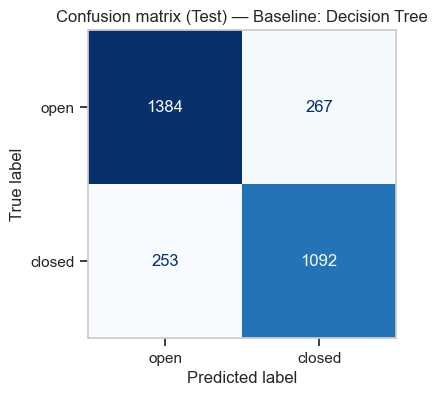

,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy
model,,,,
Baseline: Decision Tree,1.0,0.826435,1.0,0.825088


In [11]:
baseline = DecisionTreeClassifier(random_state=42)

res_baseline = evaluate_classifier(
    baseline,
    X_train, X_test,
    y_train, y_test,
    title="Baseline: Decision Tree",
    class_names=class_names,
 )

pd.DataFrame([res_baseline]).set_index("model")

## 4. Cross-validation (CV)

A single train/test split gives one estimate of performance, but it can be noisy.
Cross-validation averages performance over multiple splits and is the standard tool for model selection.

We will estimate performance using **Stratified K-Fold** CV and **balanced accuracy**.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Why do we use stratification in classification CV?
- Why should we do CV on the training data (not on the test data)?
</div>


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    baseline,
    X_train, y_train,
    scoring="balanced_accuracy",
    cv=skf,
    n_jobs=-1,
)

print(f"CV balanced accuracy (5-fold): mean={cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Test balanced accuracy (single split): {res_baseline['test_balanced_accuracy']:.3f}")

CV balanced accuracy (5-fold): mean=0.823 ± 0.005
Test balanced accuracy (single split): 0.825


## 5. Optimizing one hyperparameter (manual CV sweep)

For Decision Trees, a key hyperparameter is **max_depth** (how deep the tree is allowed to grow).
We will sweep over a range of `max_depth` values and evaluate each setting using cross-validation.


<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- What happens when `max_depth` is very small?
- What happens when `max_depth` is very large (or unlimited)?
- Why is it better to pick `max_depth` using CV rather than the test set?
- Change the scoring metric to `roc_auc_score` and repeat the hyperparameter sweep. How do the results change? (Hint: if you want to compute the AUC score, you need to use the predicted probabilities of the positive class, not the hard class labels)
- Add code to plot the CV results on the training folds. How does the training performance change with max_depth?
</div>


Best max_depth by CV: 17 (mean score=0.828)


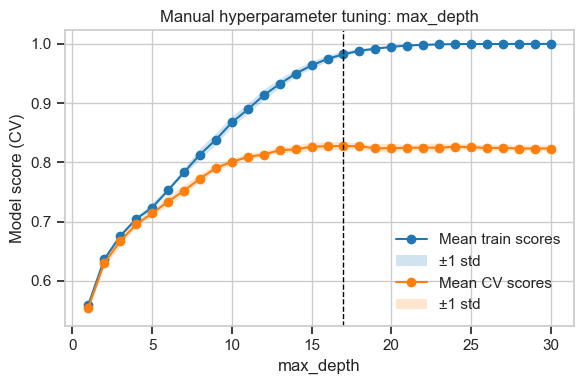

In [13]:
from sklearn.metrics import roc_auc_score
depth_values = list(range(1, 31)) # max_depth from 1 to 30
scoring_metric = balanced_accuracy_score

train_mean_scores = []
train_std_scores = []
validation_mean_scores = []
validation_std_scores = []

# Compute the train and validation scores for each max_depth
for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Cross-validation
    train_scores = []
    validation_scores = []
    for fold in skf.split(X_train, y_train):
        # Fit the model on the training fold
        model.fit(X_train[fold[0]], y_train[fold[0]])

        # Evaluate on training fold
        train_pred = model.predict(X_train[fold[0]])
        train_scores.append(scoring_metric(y_train[fold[0]], train_pred))

        # Evaluate on validation fold
        validation_pred = model.predict(X_train[fold[1]])
        validation_scores.append(scoring_metric(y_train[fold[1]], validation_pred))

    # Store mean and std of scores  
    train_mean_scores.append(np.mean(train_scores))
    train_std_scores.append(np.std(train_scores))
    validation_mean_scores.append(np.mean(validation_scores))
    validation_std_scores.append(np.std(validation_scores))

# Convert to numpy arrays for easier indexing
train_mean_scores = np.array(train_mean_scores)
train_std_scores = np.array(train_std_scores)
validation_mean_scores = np.array(validation_mean_scores)
validation_std_scores = np.array(validation_std_scores)

# Identify best max_depth based on validation scores
best_idx = int(np.argmax(validation_mean_scores))
best_depth = int(depth_values[best_idx])

print(f"Best max_depth by CV: {best_depth} (mean score={validation_mean_scores[best_idx]:.3f})")

# Plot the results
plt.figure(figsize=(6, 4))
plt.plot(depth_values, train_mean_scores, marker="o", label="Mean train scores")
plt.fill_between(depth_values, train_mean_scores - train_std_scores, train_mean_scores + train_std_scores, alpha=0.2, label="±1 std")
plt.plot(depth_values, validation_mean_scores, marker="o", label="Mean CV scores")
plt.fill_between(depth_values, validation_mean_scores - validation_std_scores, validation_mean_scores + validation_std_scores, alpha=0.2, label="±1 std")
plt.axvline(best_depth, color="k", linestyle="--", linewidth=1)
plt.xlabel("max_depth")
plt.ylabel("Model score (CV)")
plt.title("Manual hyperparameter tuning: max_depth")
plt.legend()
plt.tight_layout()
plt.show()

Now we will retrain the Decision Tree with the best `max_depth` on the full training set, and evaluate it on the held-out test set.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- How does the test performance compare to the CV performance?
- How does the optimized model compare to the baseline model from before?
- How would you summarize the purpose of cross-validation in model selection?
</div>

Tuned (1 param): Decision Tree (max_depth=17)
Train accuracy: 0.977 | Test accuracy: 0.828
Train balanced acc: 0.976 | Test balanced acc: 0.825

Classification report (Test):
              precision    recall  f1-score   support

        open       0.84      0.85      0.84      1651
      closed       0.81      0.80      0.81      1345

    accuracy                           0.83      2996
   macro avg       0.83      0.83      0.83      2996
weighted avg       0.83      0.83      0.83      2996



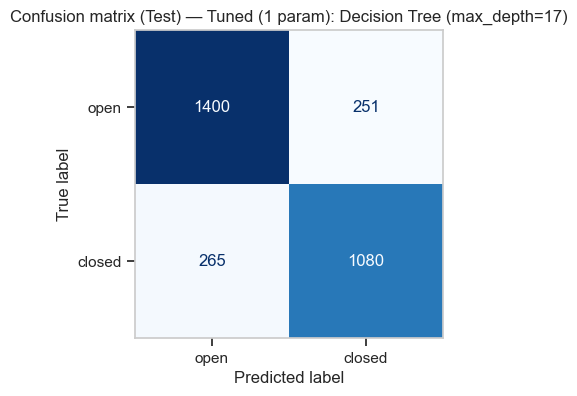

,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy
model,,,,
Tuned (1 param): Decision Tree (max_depth=17),0.976969,0.827770,0.975757,0.825472
Baseline: Decision Tree,1.000000,0.826435,1.000000,0.825088


In [14]:
best_single = DecisionTreeClassifier(max_depth=best_depth, random_state=42)

res_best_single = evaluate_classifier(
    best_single,
    X_train, X_test,
    y_train, y_test,
    title=f"Tuned (1 param): Decision Tree (max_depth={best_depth})",
    class_names=class_names,
 )

pd.DataFrame([res_baseline, res_best_single]).set_index("model").sort_values("test_balanced_accuracy", ascending=False)

## 6. Optimizing multiple hyperparameters (GridSearchCV and RandomizedSearchCV)

In the previous section, we manually tuned one hyperparameter (`max_depth`) by sweeping over a range of values.

In practice, we often want to tune multiple hyperparameters at once.

Now we will tune the Decision Tree across multiple hyperparameters simultaneously (maximum depth, minimum number of samples to split, minimum number of samples per leaf, and maximum number of features) using **GridSearchCV** and **RandomizedSearchCV**.

- **Grid search** tries *all* combinations in a fixed grid (can be expensive).
- **Randomized search** samples a fixed number of combinations (often more efficient).

We use **balanced accuracy** as scoring metric again to determine the best hyperparameter combination.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Compare the best hyperparameter combinations found by GridSearchCV and RandomizedSearchCV. Are they similar?
- How do the CV performances of the best models from GridSearchCV and RandomizedSearchCV compare?
</div>

In [15]:
tree = DecisionTreeClassifier(random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    "max_depth": [None, 3, 5, 7, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"],
}

# Set up GridSearchCV
grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=skf,
    n_jobs=-1,
    refit=True,
    verbose=1
)

# Fit the grid search
grid.fit(X_train, y_train)
print("GridSearch best CV balanced acc:", round(grid.best_score_, 4))
print("GridSearch best params:", grid.best_params_)

Fitting 5 folds for each of 189 candidates, totalling 945 fits
GridSearch best CV balanced acc: 0.8267
GridSearch best params: {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [16]:
rand = RandomizedSearchCV(
    estimator=tree,
    param_distributions=param_grid,
    n_iter=30,
    scoring="balanced_accuracy",
    cv=skf,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rand.fit(X_train, y_train)
print("RandomizedSearch best CV balanced acc:", round(rand.best_score_, 4))
print("RandomizedSearch best params:", rand.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RandomizedSearch best CV balanced acc: 0.8229
RandomizedSearch best params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}


Selected by GridSearchCV
Train accuracy: 0.950 | Test accuracy: 0.834
Train balanced acc: 0.948 | Test balanced acc: 0.831

Classification report (Test):
              precision    recall  f1-score   support

        open       0.84      0.86      0.85      1651
      closed       0.83      0.80      0.81      1345

    accuracy                           0.83      2996
   macro avg       0.83      0.83      0.83      2996
weighted avg       0.83      0.83      0.83      2996



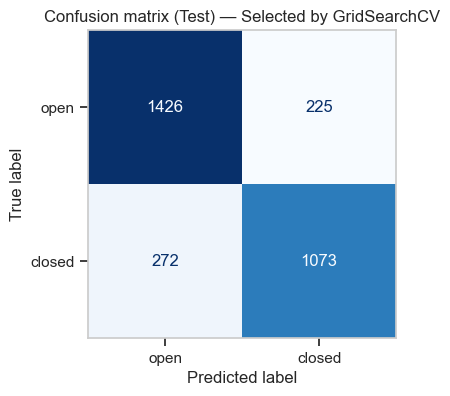

Selected by RandomizedSearchCV
Train accuracy: 0.985 | Test accuracy: 0.833
Train balanced acc: 0.984 | Test balanced acc: 0.831

Classification report (Test):
              precision    recall  f1-score   support

        open       0.85      0.85      0.85      1651
      closed       0.82      0.81      0.81      1345

    accuracy                           0.83      2996
   macro avg       0.83      0.83      0.83      2996
weighted avg       0.83      0.83      0.83      2996



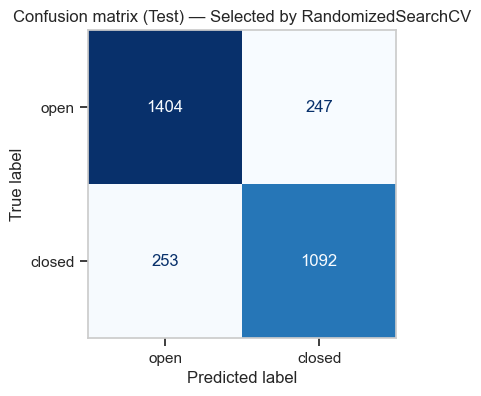

,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy
model,,,,
Selected by RandomizedSearchCV,0.985063,0.833111,0.984136,0.831145
Selected by GridSearchCV,0.950434,0.834112,0.947661,0.830744
Tuned (1 param): Decision Tree (max_depth=17),0.976969,0.827770,0.975757,0.825472
Baseline: Decision Tree,1.000000,0.826435,1.000000,0.825088


In [17]:
# Final evaluation on the held-out test set (once)
res_grid = evaluate_classifier(
    grid.best_estimator_,
    X_train, X_test,
    y_train, y_test,
    title="Selected by GridSearchCV",
    class_names=class_names,
)

res_rand = evaluate_classifier(
    rand.best_estimator_,
    X_train, X_test,
    y_train, y_test,
    title="Selected by RandomizedSearchCV",
    class_names=class_names,
)

pd.DataFrame([res_baseline, res_best_single, res_grid, res_rand]).set_index("model").sort_values("test_balanced_accuracy", ascending=False)

## 8. Wrap-up

You have now seen a standard model selection workflow for classification:
- Start with a reasonable **baseline**
- Use **cross-validation** on the training set to estimate generalization
- Tune hyperparameters (one-at-a-time or multi-parameter) using CV
- Keep the **test set** for one final evaluation

---

## Optional exercises (for early finishers)


### A. Optimization across multiple classifiers

Goal: compare different model families *fairly* by tuning each one with CV and comparing the best CV score.

Suggested models to try:
- Logistic Regression
- SVM (RBF kernel)
- Random Forest

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Which model family gives the best CV balanced accuracy?
- Does the best CV model also perform best on the test set?
- What would change if you used AUC instead of balanced accuracy?
</div>


In [18]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

search_specs = {
    'LogReg': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(solver='saga', max_iter=5000, random_state=42)),
        ]),
        'param_distributions': {
            'clf__l1_ratio': list(np.linspace(0, 1, 50)),
            'clf__C': list(np.logspace(-4, 4, 50))
        },
    },
    'SVM (RBF)': {
        'estimator': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', random_state=42)),
        ]),
        'param_distributions': {
            'clf__C': list(np.logspace(-3, 3, 50)),
            'clf__gamma': list(np.logspace(-4, 1, 50)),
        },
    },
    'RandomForest': {
        'estimator': RandomForestClassifier(random_state=42),
        'param_distributions': {
            'n_estimators': list(range(100, 501, 50)),
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
        },
    },
}

results_multi = []
for name, spec in search_specs.items():
    print(f"Searching: {name}")
    rs = RandomizedSearchCV(
        estimator=spec['estimator'],
        param_distributions=spec['param_distributions'],
        n_iter=25,
        scoring='balanced_accuracy',
        cv=skf,
        n_jobs=-1,
        random_state=42,
        refit=True,
        verbose=1
    )
    rs.fit(X_train, y_train)
    test_bacc = balanced_accuracy_score(y_test, rs.best_estimator_.predict(X_test))
    results_multi.append({
        'model': name,
        'best_cv_balanced_accuracy': rs.best_score_,
        'test_balanced_accuracy': test_bacc,
        'best_params': rs.best_params_,
    })

pd.DataFrame(results_multi).sort_values('best_cv_balanced_accuracy', ascending=False)

Searching: LogReg
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Searching: SVM (RBF)
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/machine-learning-and-deep-learning-fundamentals/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Searching: RandomForest
Fitting 5 folds for each of 25 candidates, totalling 125 fits


,model,best_cv_balanced_accuracy,test_balanced_accuracy,best_params
2,RandomForest,0.922886,0.930212,"{'n_estimators': 300, 'min_samples_split': 2, ..."
1,SVM (RBF),0.921353,0.911159,"{'clf__gamma': 3.088843596477485, 'clf__C': 1...."
0,LogReg,0.584414,0.561761,"{'clf__l1_ratio': 0.1020408163265306, 'clf__C'..."


### B. Visualize a 2D loss surface (contour plot) and sampled points

Goal: build intuition for optimization by visualizing a loss surface.

We will:
- Train a decision tree classifier
- Perform randomized grid search to sample different hyperparameter combinations
- Plot a contour map and overlay randomly sampled points in the hyperparameter space

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Where is the minimum located?
- Does the loss surface look convex?
- How does the density of sampled points affect your chance of finding a good region?
</div>


Performing randomized search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best sampled point: max_depth=17, min_samples_split=7
Loss at best point: 0.1748


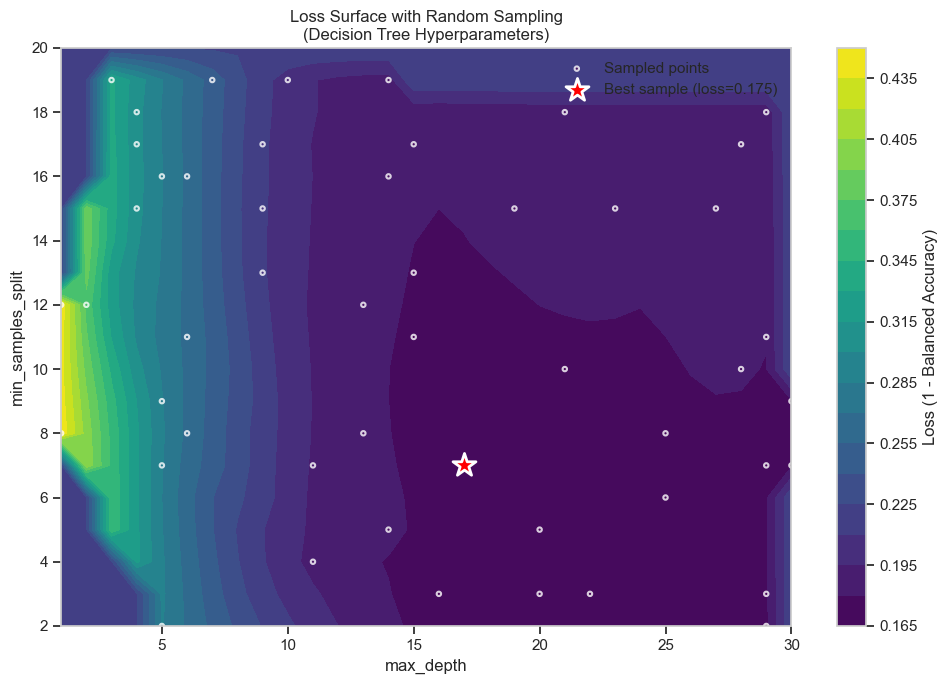

In [25]:
from scipy.interpolate import griddata

# Create a 2D hyperparameter space for max_depth and min_samples_split
# Sample random points and evaluate loss (1 - balanced_accuracy)

# Define parameter ranges
max_depth_range = np.arange(1, 31)
min_samples_split_range = np.arange(2, 21)

# Use RandomizedSearchCV to sample random points
n_random_samples = 50
param_distributions = {
    'max_depth': max_depth_range.tolist(),
    'min_samples_split': min_samples_split_range.tolist(),
}

print("Performing randomized search...")
rand_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=n_random_samples,
    scoring='balanced_accuracy',
    cv=skf,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rand_search.fit(X_train, y_train)

# Extract sampled points and their losses
cv_results = rand_search.cv_results_
random_max_depth = np.array([params['max_depth'] for params in cv_results['params']])
random_min_samples_split = np.array([params['min_samples_split'] for params in cv_results['params']])
random_losses = 1 - cv_results['mean_test_score']

# Find the best sampled point
best_sample_idx = np.argmin(random_losses)
best_max_depth = random_max_depth[best_sample_idx]
best_min_samples_split = random_min_samples_split[best_sample_idx]
best_loss = random_losses[best_sample_idx]

print(f"\nBest sampled point: max_depth={best_max_depth}, min_samples_split={best_min_samples_split}")
print(f"Loss at best point: {best_loss:.4f}")

# Create a grid for visualization (interpolate the loss surface)
grid_max_depth, grid_min_samples_split = np.meshgrid(max_depth_range, min_samples_split_range)
loss_surface = griddata(
    (random_max_depth, random_min_samples_split),
    random_losses,
    (grid_max_depth, grid_min_samples_split),
    method='cubic',
    fill_value=random_losses.mean()
)

# Plot the contour map with sampled points
plt.figure(figsize=(10, 7))
contour = plt.contourf(grid_max_depth, grid_min_samples_split, loss_surface, levels=20, cmap='viridis')
plt.colorbar(contour, label='Loss (1 - Balanced Accuracy)')

# Overlay sampled points
plt.scatter(random_max_depth, random_min_samples_split, c=random_losses, 
            s=10, cmap='viridis', edgecolors='white', linewidth=1.5, 
            label='Sampled points', alpha=0.8)

# Mark the best point
plt.scatter(best_max_depth, best_min_samples_split, c='red', s=300, 
            marker='*', edgecolors='white', linewidth=2, 
            label=f'Best sample (loss={best_loss:.3f})', zorder=5)

plt.xlabel('max_depth')
plt.ylabel('min_samples_split')
plt.title('Loss Surface with Random Sampling\n(Decision Tree Hyperparameters)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
